In [1]:
import Meshes as Meshes
using CairoMakie: CairoMakie as Makie
using Unitful: m, ustrip, Length
using LinearAlgebra: cross, dot, norm
using MarineHydro
using DifferentiationInterface 
import ForwardDiff 

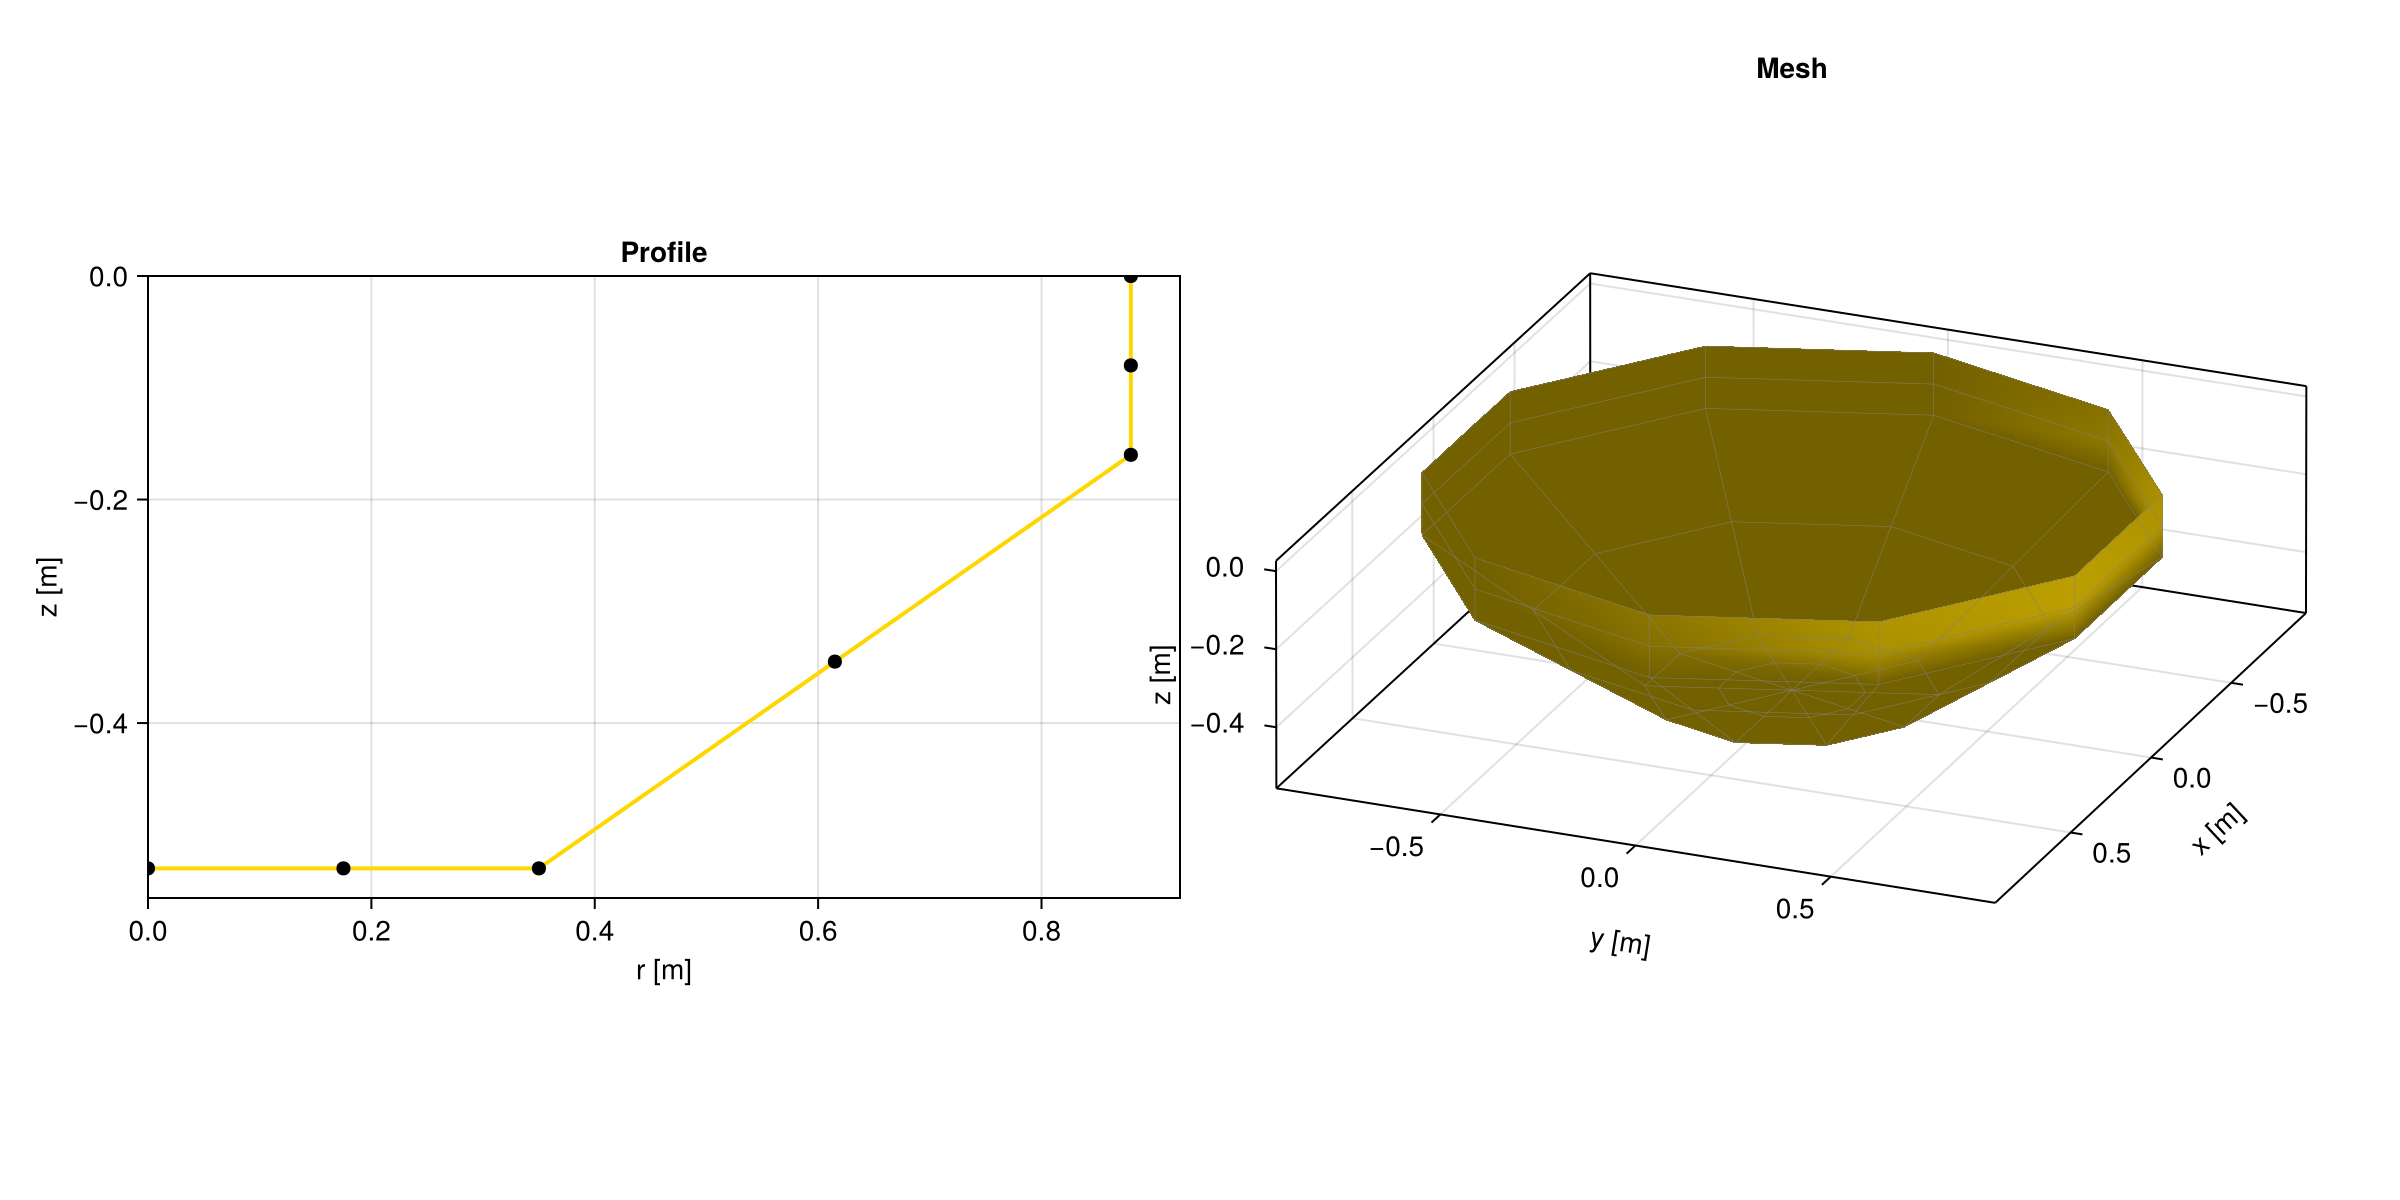

Mesh([0.88 0.0 -0.0; 0.7119349550499537 0.5172510220173764 -0.0; … ; 0.14157797401561578 -0.10286241915118283 -0.53; 0.0 0.0 -0.53], [0 10 11 1; 1 11 12 2; … ; 58 60 59 59; 59 60 50 50], Number[0.7959674775249769 0.2586255110086882 -0.04; 0.49193495504995377 0.6770903781785558 -0.04000000000000001; … ; 0.06521864934374384 -0.08976576983427824 -0.53; 0.10552599133853859 -0.03428747305039428 -0.53], Number[0.9510565162951536 0.3090169943749474 0.0; 0.587785252292473 0.8090169943749473 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.043509592807992596, 0.0435095928079926, 0.04350959280799259, 0.04350959280799259, 0.0435095928079926, 0.043509592807992596, 0.043509592807992596, 0.04350959280799259, 0.04350959280799259, 0.04350959280799262  …  0.009000461675728494, 0.009000461675728492, 0.009000461675728492, 0.009000461675728494, 0.009000461675728494, 0.009000461675728494, 0.009000461675728492, 0.009000461675728492, 0.009000461675728495, 0.009000461675728497], Number[0.2748610917864156, 0.274861091

In [28]:
r1 = 0.88
r2 = 0.35
d1 = 0.16
d2 = 0.37
n_points = (3, 3, 3)
n_theta = 10
show_plot = true


mhmesh = wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)

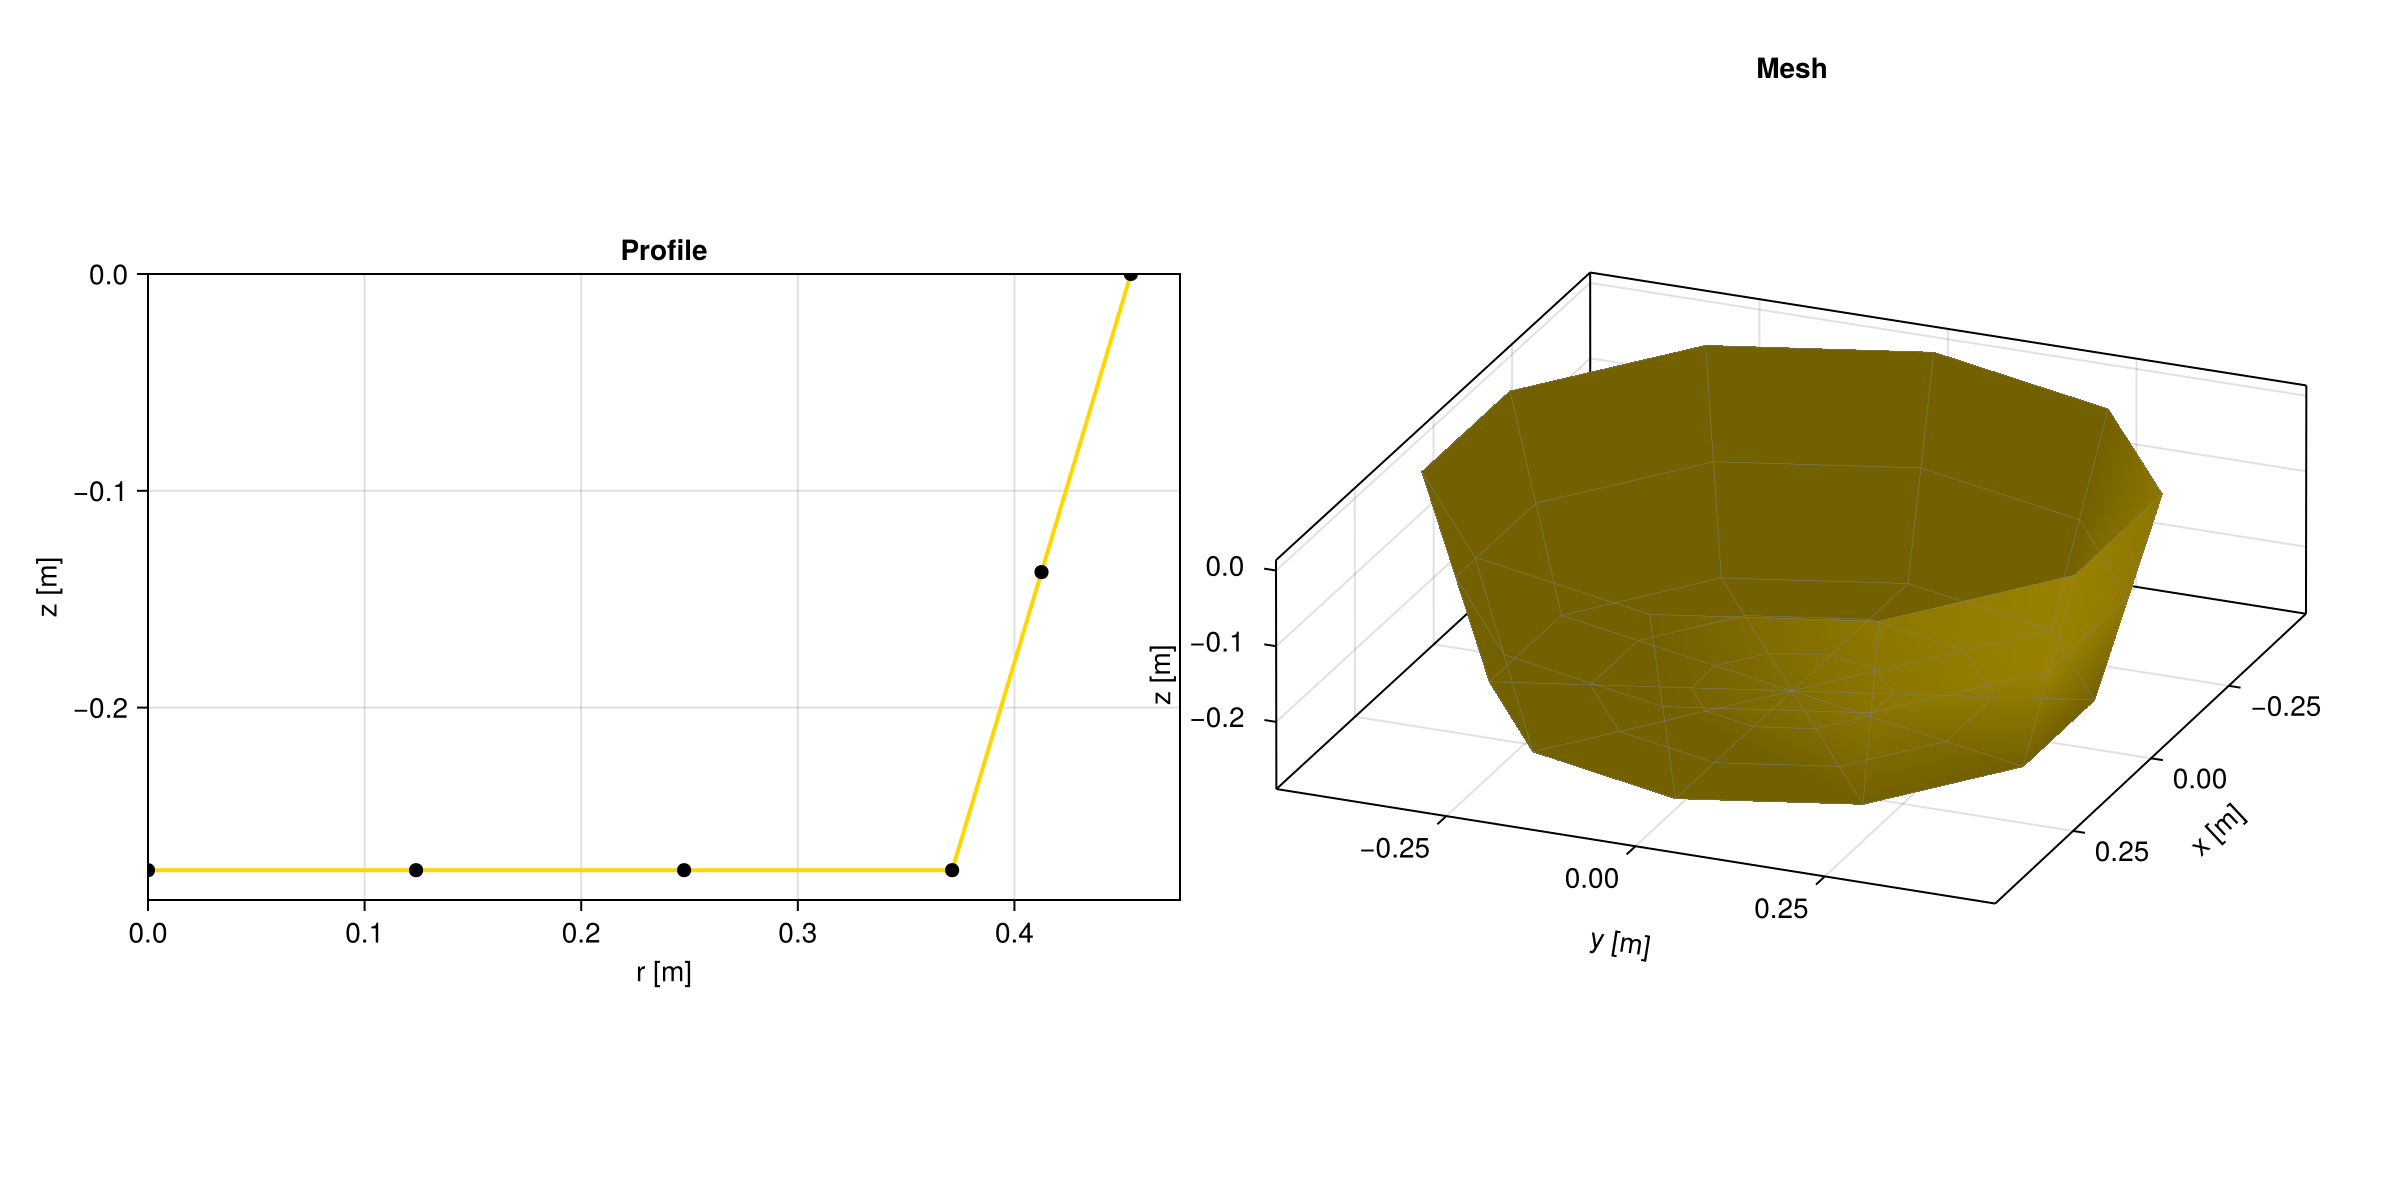

Mesh([0.4537500000000001 0.0 0.0; 0.3670914611976325 0.26670755822770975 0.0; … ; 0.10011585305389974 -0.07273842497119358 -0.275; 0.0 0.0 -0.275], [0 10 11 1; 1 11 12 2; … ; 48 50 49 49; 49 50 40 40], Number[0.39206136169757055 0.12738845854743422 -0.06765873015873015; 0.24230724720466476 0.3335073142516399 -0.06765873015873015; … ; 0.046118902035933156 -0.06347722295423962 -0.275; 0.07462195101796658 -0.024246141657064527 -0.275], Number[0.9145595421477449 0.2971584086215512 -0.2743678626443235; 0.5652288817828484 0.7779708138140508 -0.2743678626443236; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.038275656645799745, 0.038275656645799745, 0.03827565664579974, 0.03827565664579974, 0.03827565664579975, 0.03827565664579975, 0.038275656645799745, 0.03827565664579974, 0.03827565664579974, 0.038275656645799766  …  0.004500690045092601, 0.0045006900450926006, 0.0045006900450926, 0.0045006900450926006, 0.004500690045092601, 0.004500690045092601, 0.0045006900450926006, 0.0045006900450926, 0.0045006900

In [50]:
radii_upper = 1.0
radii_lower = 0.1
draft_upper = 2.0
draft_lower = 0.25



r_initial = 0.5
n_side = 4-1 # number of design vars-1 (draft is also a design var)

# inputs
# r_side = ones(n_side) * r_initial
# r_side = collect(range(0.5, 0.001, length=n_side)) # last radius cannot be zero
# draft = draft_lower
# r_side = ones(n_side) * (radii_upper+radii_lower)/2 * 0.75
rad_ref = (radii_upper+radii_lower)/2 * 0.75
r_side = collect(range(rad_ref*1.1, rad_ref*0.9, length=n_side))
x_val = vcat(r_side,draft)

# r_side = ones(n_side) * (radii_upper+radii_lower)/2 
# draft_nom = (draft_lower+draft_upper)/2
# x_val = vcat(r_side,draft)




function arbitrary_axisymmetric_mesh(x::Vector, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-0.0, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    n_bottom = 3

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    n_theta = 10

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

arbitrary_axisymmetric_mesh(x::Vector) = arbitrary_axisymmetric_mesh(x, false)

arbitrary_axisymmetric_mesh(x_val, true)

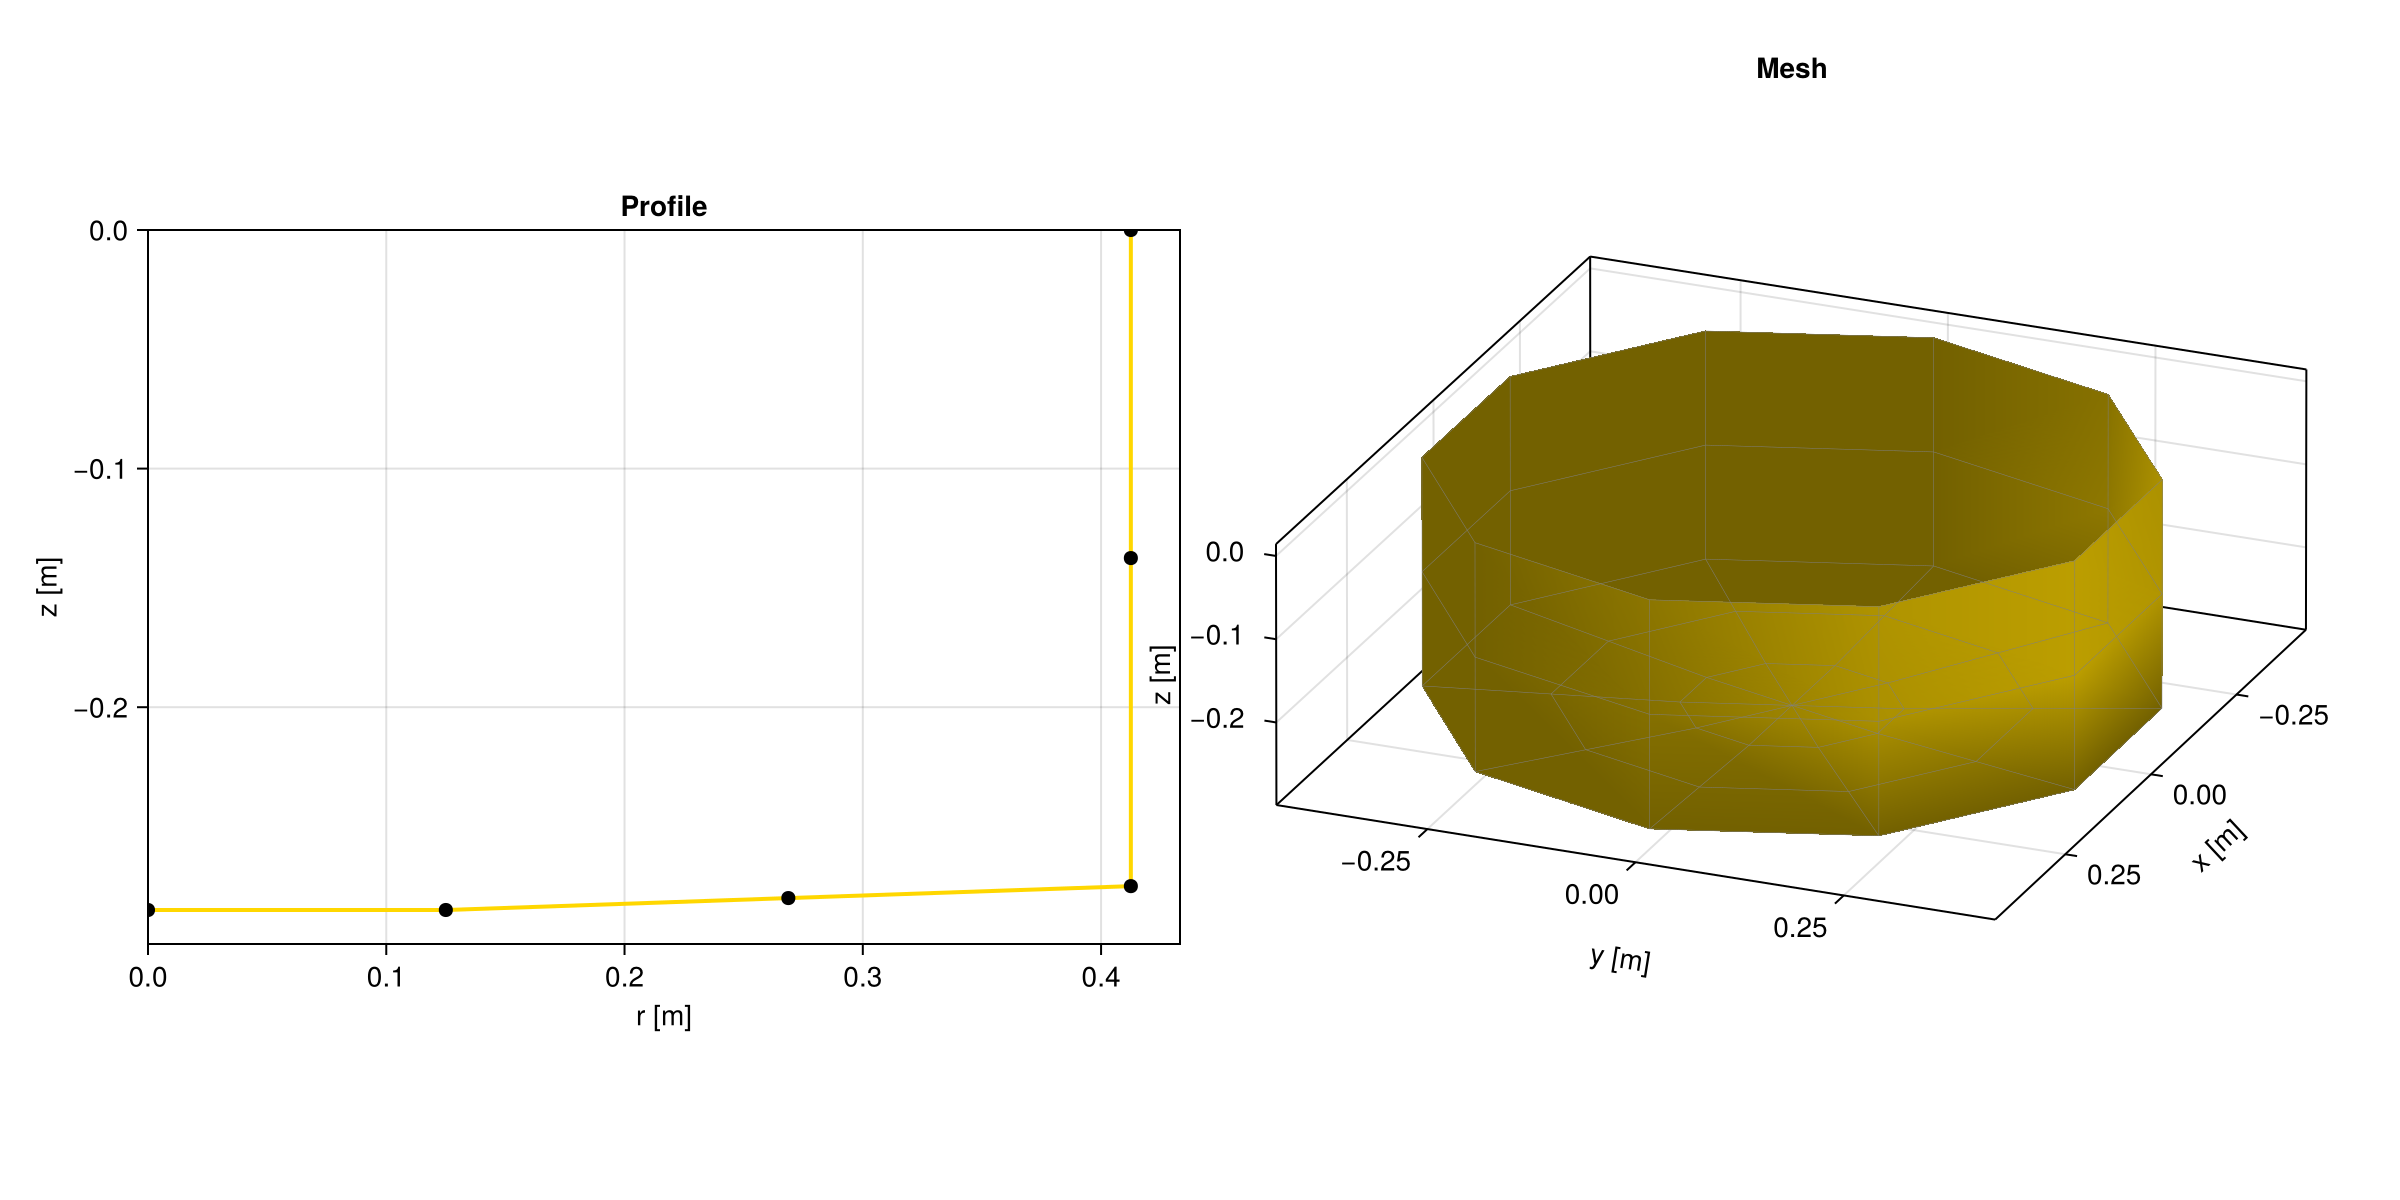

Mesh([0.41250000000000003 0.0 -0.0; 0.33371951017966583 0.24246141657064518 -0.0; … ; 0.10112712429686842 -0.07347315653655917 -0.28500000000000003; 0.0 0.0 -0.28500000000000003], [0 10 11 1; 1 11 12 2; … ; 48 50 49 49; 49 50 40 40], Number[0.3731097550898329 0.12123070828532259 -0.06875; 0.2305945101796658 0.31738611477119805 -0.06875; … ; 0.046584749531245605 -0.06411840702448446 -0.28500000000000003; 0.07537570809895615 -0.024491052178853057 -0.28500000000000003], Number[0.9510565162951536 0.3090169943749475 0.0; 0.5877852522924731 0.8090169943749473 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.0350541152994081, 0.0350541152994081, 0.035054115299408106, 0.0350541152994081, 0.035054115299408106, 0.035054115299408106, 0.0350541152994081, 0.03505411529940809, 0.0350541152994081, 0.03505411529940812  …  0.004592072283534946, 0.004592072283534946, 0.0045920722835349455, 0.004592072283534946, 0.004592072283534946, 0.004592072283534946, 0.004592072283534946, 0.0045920722835349455, 0.0045920722

In [40]:
r1 = r_side[1]
r2 = 0.125
d1 = draft
d2 = 0.01
n_points = (2, 3, 3)
n_theta = 10
show_plot = true


mhmesh = wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)

In [41]:
function wb_mesh(x)
    r1=x[1]
    r2=x[2]
    d1=x[3]
    d2=x[4]
    n_points=(3, 3, 3)
    n_theta = 10
    show_plot = false
    return wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)
end
x_wb = [r1,r2,d1,d2]
wb_mesh(x_wb)

Mesh([0.41250000000000003 0.0 -0.0; 0.33371951017966583 0.24246141657064518 -0.0; … ; 0.05056356214843421 -0.036736578268279585 -0.28500000000000003; 0.0 0.0 -0.28500000000000003], [0 10 11 1; 1 11 12 2; … ; 58 60 59 59; 59 60 50 50], Number[0.3731097550898329 0.12123070828532259 -0.06875; 0.2305945101796658 0.31738611477119805 -0.06875; … ; 0.023292374765622802 -0.03205920351224223 -0.28500000000000003; 0.037687854049478074 -0.012245526089426528 -0.28500000000000003], Number[0.9510565162951536 0.3090169943749475 0.0; 0.5877852522924731 0.8090169943749473 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.0350541152994081, 0.0350541152994081, 0.035054115299408106, 0.0350541152994081, 0.035054115299408106, 0.035054115299408106, 0.0350541152994081, 0.03505411529940809, 0.0350541152994081, 0.03505411529940812  …  0.0011480180708837366, 0.0011480180708837366, 0.0011480180708837364, 0.0011480180708837366, 0.0011480180708837366, 0.0011480180708837366, 0.0011480180708837366, 0.0011480180708837364, 0.00

In [5]:
MH_mesh = arbitrary_axisymmetric_mesh(x_val)

Mesh([0.41250000000000003 0.0 0.0; 0.33371951017966583 0.24246141657064518 0.0; … ; 0.11123983672655527 -0.0808204721902151 -0.25; 0.0 0.0 -0.25], [0 10 11 1; 1 11 12 2; … ; 48 50 49 49; 49 50 40 40], Number[0.37310975508983296 0.12123070828532258 -0.0625; 0.23059451017966584 0.31738611477119805 -0.0625; … ; 0.05124322448437017 -0.07053024772693291 -0.25; 0.08291327890885176 -0.026940157396738367 -0.25], Number[0.9510565162951536 0.30901699437494745 0.0; 0.5877852522924731 0.8090169943749476 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491646, 0.03186737754491645, 0.03186737754491645, 0.031867377544916455, 0.03186737754491647  …  0.005556407463077286, 0.005556407463077286, 0.005556407463077286, 0.005556407463077286, 0.005556407463077287, 0.005556407463077286, 0.005556407463077284, 0.005556407463077286, 0.005556407463077286, 0.0055564074630772885], Number[0.1419673414044368

In [6]:
backend = AutoForwardDiff()

function surface_area(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(MH_mesh.areas)
end

function compute_SA_and_gradient(x_val)
    return value_and_gradient(x -> surface_area(x), backend, x_val)
end

compute_SA_and_gradient (generic function with 1 method)

In [7]:
# compute_SA_and_gradient(x_val)

In [8]:
theoretical_SA = pi * r_initial * sqrt(draft^2 + r_initial^2)

0.8781018413800908

In [9]:
function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

hydrostatic_program (generic function with 1 method)

In [10]:


# Hydrostatics
function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

# Radiation
function radiation_program(mesh, omega, dof) 
    A, B = calculate_radiation_forces(mesh,dof,omega)
    # display("Damping: $B")
    return [A, B]
end

# Diffraction
function diffraction_program(mesh, omega, dof) 
    F_D = DiffractionForce(mesh,omega,dof)
    return [real(F_D),imag(F_D)]
end

function incident_program(mesh, omega, dof) 
    F_FK = FroudeKrylovForce(mesh,omega,dof)
    return [real(F_FK),imag(F_FK)]
end

# Everything
dof = [0.0,0.0,1.0]

function compute_for_omega(mesh, omega)

    # M, K = hydrostatic_program(r1, r2, d1, d2)
    A, B = radiation_program(mesh, omega, dof)
    F_D_real, F_D_imag = diffraction_program(mesh, omega, dof) 
    F_FK_real, F_FK_imag = incident_program(mesh, omega, dof)
    # add negatives to imag since wot uses +i omega t instead of -i omega t
    return [A, B, F_D_real, -F_D_imag, F_FK_real, -F_FK_imag]
end

backend = AutoForwardDiff()


function arbitrary_axisymmetric_mesh(x, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-1e-3, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    n_bottom = 3

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    n_theta = 10

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

arbitrary_axisymmetric_mesh(x) = arbitrary_axisymmetric_mesh(x, false)


function compute_vals(x, omegas)
    set_rho!(1025.0)
    x=vec(x)
    mesh = arbitrary_axisymmetric_mesh(x)    
    M_val, K_val = hydrostatic_program(x)
    results_per_omega = [compute_for_omega(mesh, omega) for omega in omegas]
    vec_reduced = reduce(vcat, results_per_omega)
    
    return [M_val; K_val; vec_reduced]
end

function compute_all(x_val, omegas)
    return value_and_jacobian(x -> compute_vals(x, omegas), backend, x_val)
end


function surface_area(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(MH_mesh.areas)
end


function centers(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(abs.(MH_mesh.centers[:,1]))
end

function compute_SA_and_gradient(x_val)
    return value_and_gradient(x -> surface_area(x), backend, x_val)
end

compute_SA_and_gradient (generic function with 1 method)

In [11]:
2*pi*0.3

1.8849555921538759

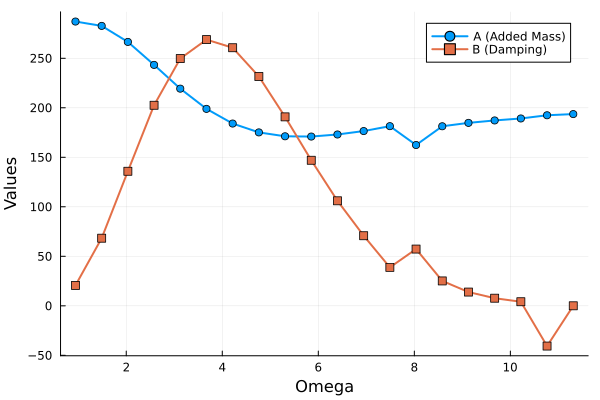

In [12]:
using Plots

omega = 2*pi*0.3


num_omegas = 20
omegas = collect(range(omega/2,6*omega,length=num_omegas))
dof = [0.0,0.0,1.0]

A = zeros(num_omegas)
B = zeros(num_omegas)

for i in 1:num_omegas
    omega = omegas[i]    
    A[i], B[i] = radiation_program(mhmesh, omega, dof)
end

plot(omegas, A, label="A (Added Mass)", xlabel="Omega", ylabel="Values", linewidth=2, marker=:circle)
plot!(omegas, B, label="B (Damping)", linewidth=2, marker=:square)    

In [49]:
rad = (radii_upper+radii_lower)/2 * 0.75
r_side = ones(n_side) * (radii_upper+radii_lower)/2 * 0.75

num_r = 20
r_vals = collect(range(0.9*rad,1.1*rad,length=num_r))
# d_vals = collect(range(0.9*draft_lower,1.1*draft_lower,length=num_r))
dof = [0.0,0.0,1.0]



A = zeros(num_r)
B = zeros(num_r)

for i in 1:num_r  
    # draft = d_vals[i]
    r_side[2] = r_vals[i]
    x_new = vcat(r_side,draft) 
    new_mesh = arbitrary_axisymmetric_mesh(x_new)
    A[i], B[i] = radiation_program(new_mesh, omega, dof)
end

plot(r_vals, A, label="A (Added Mass)", xlabel="Radius [m]", ylabel="Values", linewidth=2, marker=:circle)
plot!(r_vals, B, label="B (Damping)", linewidth=2, marker=:square)  

In [48]:
B

20-element Vector{Float64}:
 11.895780599465297
  9.496766901374022
  7.247448450038545
  5.200560270346045
  3.409736928083078
  1.927008068814057
  0.7996052741751126
  0.06602730247462409
 -0.24797448115827062
 -0.13489885329306697
  0.3918403626954961
  1.2904134619602028
  2.4905311031787445
  3.8915666842363823
  5.364207189136019
  6.755501457012657
  7.897936502860174
  8.622966596638564
  8.779107028972636
  8.254272856865777

In [51]:
all_out = compute_all(x_val, [omega, 2*omega])

([150.63207114525576, 6503.932443077699, 99.91628383115774, -7.14383392945092, 64.9632427302797, -40.76698151348949, -49.171779665140384, 1.7985612998927536e-14, 107.10990914849216, -1.4100845047792385, -97.18775273567209, 0.3054085133857247, 18.232630705678748, 1.909032692126375e-14], [194.10958528735262 363.9554724137862 169.84588712643352 549.7520844717362; 28667.470823482963 0.0 0.0 0.0; … ; 172.07343515210158 -741.4505839740581 -0.24357705241884214 -234.35651589508637; 7.531752999057062e-13 -2.417302469304161e-13 7.849623728795052e-17 -2.5554525943244366e-13])

In [52]:
all_out[2]

14×4 Matrix{Float64}:
   194.11           363.955         169.846         549.752
 28667.5              0.0             0.0             0.0
    12.7127         523.354         363.356         116.367
 -1005.52         -2954.94          329.584        -613.74
  1246.59          2328.9          -306.824         897.098
  3825.29          8258.2           226.213        2345.16
   492.5           1143.3           250.684         402.909
    -2.27374e-13      2.27374e-13    -3.14415e-13     3.606e-13
   209.821          250.75          311.985          33.4132
   -52.9002         193.696          21.3516         41.9328
 -2613.84          1879.16          317.463         871.206
    20.8221          87.446           0.479195      -18.5907
   172.073         -741.451          -0.243577     -234.357
     7.53175e-13     -2.4173e-13      7.84962e-17    -2.55545e-13

In [53]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, x -> compute_vals(x, [omega, 2*omega]), x_val)[1]


14×4 Matrix{Float64}:
   194.11           363.955         169.846         549.752
 28667.5              1.09434e-8      4.68859e-9      3.5073e-9
     6.99228        489.41          380.329         116.367
  -893.749        -2291.92           -1.92624      -613.74
  1218.17          2125.57         -205.157         897.098
  3807.53          8135.29          287.664        2345.16
   492.5           1143.3           250.684         402.909
     7.16613e-10      2.72873e-9     -1.35835e-10     2.8514e-10
   206.415          234.37          320.175          33.4132
   -49.756          210.851          12.7738         41.9328
 -2605.14          1873.5           320.295         871.206
    21.1693          89.8551         -0.725348      -18.5907
   172.073         -741.451          -0.243577     -234.357
     2.12155e-11     -4.05775e-10    -2.11803e-13    -6.0504e-11

In [17]:
# J

In [18]:
SA_grad = value_and_gradient(x -> surface_area(x), backend, x_val)

(1.1374242225752862, [0.3862712429686843, 0.7725424859373686, 2.810885408675137, 2.5493902035933163])

In [19]:
SA_grad[2]

4-element Vector{Float64}:
 0.3862712429686843
 0.7725424859373686
 2.810885408675137
 2.5493902035933163

In [20]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.grad(method, x -> surface_area(x), x_val)[1]


4-element Vector{Float64}:
 0.3862712429688895
 0.772542485937237
 2.8108854086752895
 2.549390203593285

In [21]:
centers(x_val)
centers_grad = value_and_gradient(x -> centers(x), backend, x_val)
centers_grad[2]

4-element Vector{Float64}:
  2.9270509831248424
  5.854101966249683
 12.206886692587311
 -1.5543122344752192e-15

In [22]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.grad(method, x -> centers(x), x_val)[1]

4-element Vector{Float64}:
  2.927050983126427
  5.854101966248544
 12.206886692592693
  5.5399110039547584e-14

In [23]:
#verify derivatives wrt omega work?
der_wrt_omega = derivative(o -> compute_for_omega(MH_mesh, o), backend, omega)

6-element Vector{Float64}:
   0.5235928937453522
  -2.076110473005794
 -36.44274331369661
 -22.325833763011396
  16.76609922669094
  -3.552713678800501e-15

In [24]:
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, o -> compute_for_omega(MH_mesh, o), omega)[1]


6×1 Matrix{Float64}:
   0.5235928977837006
  -2.0761104734096443
 -36.44274333574144
 -22.325833770230325
  16.766099226724094
  -1.10797674834549e-11

In [36]:
function wb_coeffs(x_wb,omega)
    mesh = wb_mesh(x_wb)
    return compute_for_omega(mesh, omega)
end

wb_coeffs (generic function with 1 method)

In [42]:
wb_jac = value_and_jacobian(x -> wb_coeffs(x,omega), backend, x_wb)
wb_jac[2]

6×4 Matrix{Float64}:
  854.169        -22.0079        56.6119       -204.718
  -30.3428         1.23952       12.1565         -3.94839
  -70.3105       -83.9607       -33.2385        -92.7038
 -401.287         16.4214       154.82          -50.4645
 -124.605         33.5314       300.321           6.70565
   -1.10134e-13   -4.57412e-14   -2.73115e-14     4.66294e-15

In [43]:
using FiniteDifferences
method = central_fdm(5, 1)
J = FiniteDifferences.jacobian(method, x -> wb_coeffs(x,omega), x_wb)[1]


6×4 Matrix{Float64}:
  854.169        -22.0079        56.6119       -204.718
  -30.3428         1.23952       12.1565         -3.94839
  -70.3105       -83.9607       -33.2385        -92.7038
 -401.287         16.4214       154.82          -50.4645
 -124.605         33.5314       300.321           6.70565
   -6.69987e-12    3.60843e-11    1.62829e-10    -9.20871e-11